<a href="https://colab.research.google.com/github/ihmkusuma/computer-vision-assignment-ilham-kusuma-4222311030/blob/main/Extended_MNIST_Dataset_HOG_SVM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMNIST Letters Classification
## HOG Feature Extraction + SVM Classifier
### Midterm Project - Computer Vision
**Nama:** Ilham Kusuma
**NIM:** 4222311030

---
**Pipeline:**
1. Load & Prepare Dataset (2600 samples, 26 kelas, balanced)
2. Visualisasi Data
3. HOG Feature Extraction
4. SVM Classification dengan Grid Search
5. Evaluasi: LOOCV, Confusion Matrix, Accuracy, Precision, Recall, F1-Score

## 0. Install & Import Library

In [1]:
# Install library ke Python kernel yang sedang aktif
import sys
print('Python path:', sys.executable)
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'scikit-image'])
print('Install selesai! Restart Runtime lalu jalankan cell berikutnya.')


Python path: /usr/bin/python3
Install selesai! Restart Runtime lalu jalankan cell berikutnya.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    LeaveOneOut, cross_val_score, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import time
import os

print(" Semua library berhasil diimport!")
print(f"NumPy  : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
import sklearn; print(f"Sklearn  : {sklearn.__version__}")
import skimage; print(f"Skimage  : {skimage.__version__}")

 Semua library berhasil diimport!
NumPy  : 2.0.2
Pandas  : 2.2.2
Sklearn  : 1.6.1
Skimage  : 0.25.2


## 1. Dataset Preparation

### 1.1 Load Dataset

> **Catatan:** Download dataset dari Kaggle terlebih dahulu.
> Link: https://www.kaggle.com/datasets/crawford/emnist/data
> File yang digunakan: `emnist-letters-train` dan `emnist-letters-test` (dengan atau tanpa ekstensi `.csv`)
> Letakkan file di folder yang sama dengan notebook ini.

**Format Dataset:**
- Kolom 0: `class_label` (1–26, mewakili huruf A–Z)
- Kolom 1–784: nilai pixel (gambar 28×28 yang di-flatten)

In [3]:
# ============================================================
# KONFIGURASI PATH DATASET
# File CSV disimpan di folder sample_data Google Colab
# ============================================================

def find_dataset_file(base_name):
    """Cari file dataset di berbagai lokasi umum Google Colab."""
    candidates = [
        f'/content/sample_data/{base_name}',
        f'/content/sample_data/{base_name}.csv',
        f'/content/{base_name}',
        f'/content/{base_name}.csv',
        base_name,
        base_name + '.csv',
    ]
    for path in candidates:
        if os.path.exists(path):
            print(f'   Ditemukan: {path}')
            return path
    raise FileNotFoundError(
        f"File '{base_name}' tidak ditemukan.\n"
        f"Lokasi yang dicari: {candidates}"
    )

print('Mencari file dataset...')
TRAIN_CSV = find_dataset_file('emnist-letters-train')
TEST_CSV  = find_dataset_file('emnist-letters-test')

SAMPLES_PER_CLASS = 100   # 100 sampel per kelas
NUM_CLASSES       = 26    # A-Z
TOTAL_SAMPLES     = SAMPLES_PER_CLASS * NUM_CLASSES  # 2600
RANDOM_STATE      = 42

print(f'\nTarget total sampel : {TOTAL_SAMPLES}')
print(f'Sampel per kelas    : {SAMPLES_PER_CLASS}')
print(f'Jumlah kelas        : {NUM_CLASSES}')


Mencari file dataset...
   Ditemukan: /content/sample_data/emnist-letters-train.csv
   Ditemukan: /content/sample_data/emnist-letters-test.csv

Target total sampel : 2600
Sampel per kelas    : 100
Jumlah kelas        : 26


In [4]:
def load_emnist_letters(train_path, test_path=None):
    """
    Load EMNIST Letters dataset dari file CSV.
    Kolom 0 = label (1-26), kolom 1-784 = pixel values.
    """
    print('Membaca dataset...')
    df_train = pd.read_csv(train_path, header=None)
    print(f'   Train shape : {df_train.shape}')

    if test_path and os.path.exists(test_path):
        df_test = pd.read_csv(test_path, header=None)
        print(f'   Test shape  : {df_test.shape}')
        df_all = pd.concat([df_train, df_test], ignore_index=True)
    else:
        df_all = df_train

    print(f'   Total shape : {df_all.shape}')

    X = df_all.iloc[:, 1:].values.astype('float32')
    y = df_all.iloc[:, 0].values.astype(int) - 1  # konversi 1-26 ke 0-25

    print('\nDistribusi kelas (sebelum sampling):')
    unique, counts = np.unique(y, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'   Kelas {u+1:2d} ({chr(65+u)}) : {c} sampel')

    return X, y


X_raw, y_raw = load_emnist_letters(TRAIN_CSV, TEST_CSV)
print('\nDataset berhasil dimuat!')


Membaca dataset...
   Train shape : (2715, 785)
   Test shape  : (2666, 785)
   Total shape : (5381, 785)

Distribusi kelas (sebelum sampling):
   Kelas  1 (A) : 903 sampel
   Kelas  2 (B) : 895 sampel
   Kelas  3 (C) : 918 sampel
   Kelas  4 (D) : 369 sampel
   Kelas  5 (E) : 106 sampel
   Kelas  6 (F) : 95 sampel
   Kelas  7 (G) : 95 sampel
   Kelas  8 (H) : 106 sampel
   Kelas  9 (I) : 98 sampel
   Kelas 10 (J) : 101 sampel
   Kelas 11 (K) : 97 sampel
   Kelas 12 (L) : 123 sampel
   Kelas 13 (M) : 114 sampel
   Kelas 14 (N) : 103 sampel
   Kelas 15 (O) : 101 sampel
   Kelas 16 (P) : 93 sampel
   Kelas 17 (Q) : 113 sampel
   Kelas 18 (R) : 103 sampel
   Kelas 19 (S) : 114 sampel
   Kelas 20 (T) : 109 sampel
   Kelas 21 (U) : 124 sampel
   Kelas 22 (V) : 111 sampel
   Kelas 23 (W) : 109 sampel
   Kelas 24 (X) : 82 sampel
   Kelas 25 (Y) : 105 sampel
   Kelas 26 (Z) : 94 sampel

Dataset berhasil dimuat!


### 1.2 Balanced Sampling (100 sampel per kelas)

In [5]:
def balanced_sample(X, y, samples_per_class, random_state=42):
    """
    Ambil samples_per_class sampel dari setiap kelas secara acak (balanced).
    Dataset di-shuffle terlebih dahulu sebelum sampling.
    """
    np.random.seed(random_state)
    selected_idx = []

    classes = np.unique(y)
    print(f'Melakukan balanced sampling ({samples_per_class} sampel/kelas)...')

    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        # Shuffle dulu sebelum ambil sampel
        np.random.shuffle(cls_idx)
        chosen = cls_idx[:samples_per_class]
        selected_idx.extend(chosen.tolist())
        print(f'   Kelas {cls+1:2d} ({chr(65+cls)}) -> {len(chosen)} sampel dipilih')

    # Shuffle urutan seluruh dataset
    selected_idx = np.array(selected_idx)
    np.random.shuffle(selected_idx)

    X_sampled = X[selected_idx]
    y_sampled = y[selected_idx]

    return X_sampled, y_sampled


X_sampled, y_sampled = balanced_sample(X_raw, y_raw, SAMPLES_PER_CLASS, RANDOM_STATE)

print(f'\nTotal sampel setelah balanced sampling : {X_sampled.shape[0]}')
print(f'   Shape X : {X_sampled.shape}')
print(f'   Shape y : {y_sampled.shape}')

# Verifikasi distribusi kelas
unique, counts = np.unique(y_sampled, return_counts=True)
status = 'BALANCED' if len(set(counts)) == 1 else 'TIDAK BALANCED'
print(f'\nVerifikasi: semua kelas = {counts[0]} sampel -> {status}')


Melakukan balanced sampling (100 sampel/kelas)...
   Kelas  1 (A) -> 100 sampel dipilih
   Kelas  2 (B) -> 100 sampel dipilih
   Kelas  3 (C) -> 100 sampel dipilih
   Kelas  4 (D) -> 100 sampel dipilih
   Kelas  5 (E) -> 100 sampel dipilih
   Kelas  6 (F) -> 95 sampel dipilih
   Kelas  7 (G) -> 95 sampel dipilih
   Kelas  8 (H) -> 100 sampel dipilih
   Kelas  9 (I) -> 98 sampel dipilih
   Kelas 10 (J) -> 100 sampel dipilih
   Kelas 11 (K) -> 97 sampel dipilih
   Kelas 12 (L) -> 100 sampel dipilih
   Kelas 13 (M) -> 100 sampel dipilih
   Kelas 14 (N) -> 100 sampel dipilih
   Kelas 15 (O) -> 100 sampel dipilih
   Kelas 16 (P) -> 93 sampel dipilih
   Kelas 17 (Q) -> 100 sampel dipilih
   Kelas 18 (R) -> 100 sampel dipilih
   Kelas 19 (S) -> 100 sampel dipilih
   Kelas 20 (T) -> 100 sampel dipilih
   Kelas 21 (U) -> 100 sampel dipilih
   Kelas 22 (V) -> 100 sampel dipilih
   Kelas 23 (W) -> 100 sampel dipilih
   Kelas 24 (X) -> 82 sampel dipilih
   Kelas 25 (Y) -> 100 sampel dipilih
   Kel

### 1.3 Reshape & Visualisasi Dataset

Shape gambar: (2554, 28, 28)  (N x H x W)


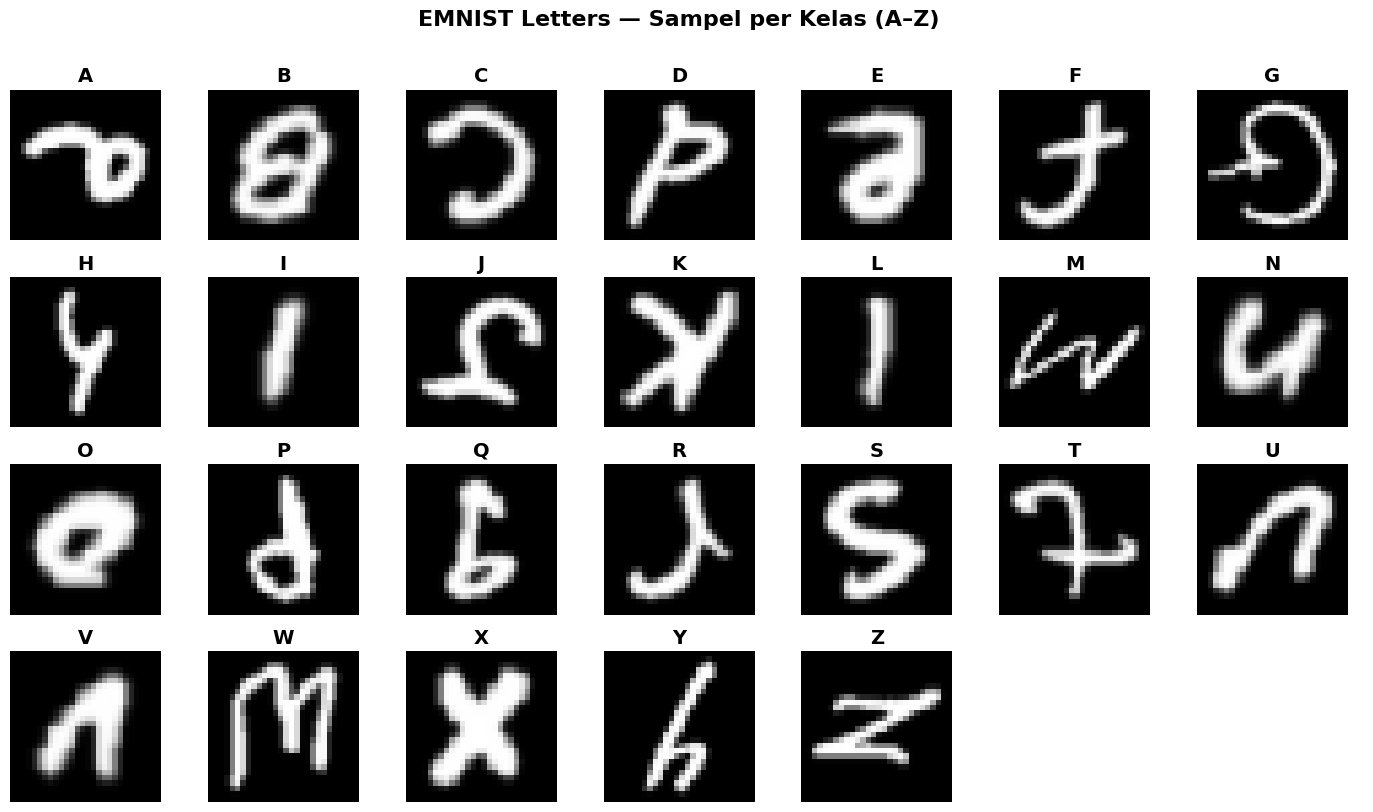

 Visualisasi kelas tersimpan sebagai 'visualisasi_kelas.png'


In [6]:
def reshape_images(X):
    """
    Reshape dari flat (784,) ke 2D (28,28).
    EMNIST perlu di-transpose karena disimpan column-major.
    """
    images = X.reshape(-1, 28, 28)
 # EMNIST disimpan dalam format transposed — rotate 90° CCW + flip horizontal
    images = np.array([np.fliplr(np.rot90(img)) for img in images])
    return images


X_images = reshape_images(X_sampled)
print(f"Shape gambar: {X_images.shape}  (N x H x W)")

# Label mapping
label_map = {i: chr(65 + i) for i in range(26)}  # 0→A, 1→B, ...

# ── Visualisasi satu gambar per kelas ──────────────────────────────────────
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
fig.suptitle('EMNIST Letters — Sampel per Kelas (A–Z)', fontsize=16, fontweight='bold', y=1.01)

for cls in range(NUM_CLASSES):
    ax = axes[cls // 7][cls % 7]
    idx = np.where(y_sampled == cls)[0][0]
    ax.imshow(X_images[idx], cmap='gray')
    ax.set_title(f'{label_map[cls]}', fontsize=14, fontweight='bold')
    ax.axis('off')

# Sembunyikan subplot kosong (posisi 26 & 27)
for i in range(NUM_CLASSES, 28):
    axes[i // 7][i % 7].axis('off')

plt.tight_layout()
plt.savefig('visualisasi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi kelas tersimpan sebagai 'visualisasi_kelas.png'")

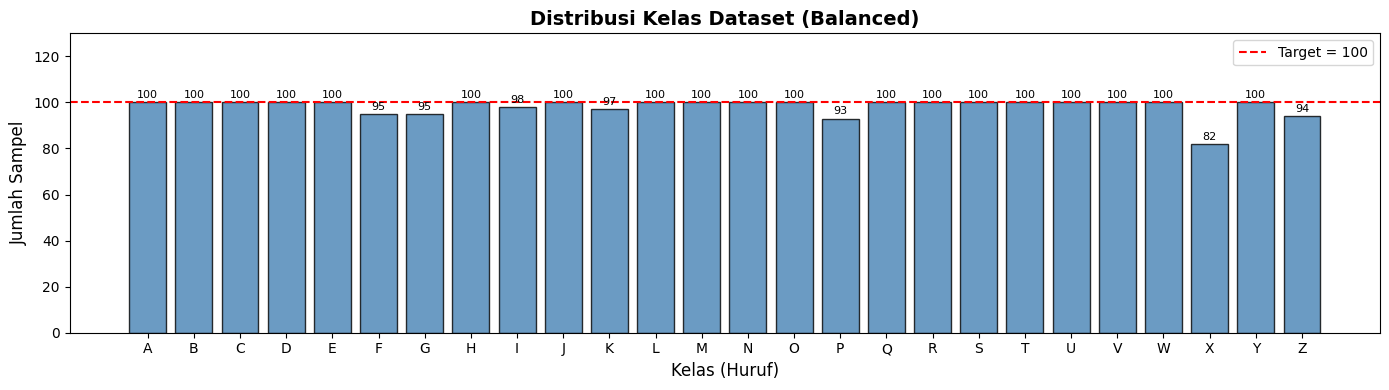

 Distribusi kelas tersimpan sebagai 'distribusi_kelas.png'


In [7]:
# ── Visualisasi distribusi kelas (bar chart) ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
classes = [label_map[i] for i in range(NUM_CLASSES)]
counts  = [np.sum(y_sampled == i) for i in range(NUM_CLASSES)]

bars = ax.bar(classes, counts, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title('Distribusi Kelas Dataset (Balanced)', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelas (Huruf)', fontsize=12)
ax.set_ylabel('Jumlah Sampel', fontsize=12)
ax.set_ylim(0, 130)
ax.axhline(y=100, color='red', linestyle='--', label='Target = 100')
ax.legend()

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
    str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Distribusi kelas tersimpan sebagai 'distribusi_kelas.png'")

## 2. HOG Feature Extraction

**Parameter HOG yang digunakan:**
| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| `orientations` | 9 | Jumlah bin histogram orientasi gradien |
| `pixels_per_cell` | (7, 7) | Ukuran tiap sel dalam pixel |
| `cells_per_block` | (2, 2) | Jumlah sel per blok untuk normalisasi |
| `block_norm` | 'L2-Hys' | Metode normalisasi blok |
| `transform_sqrt` | True | Gamma compression sebelum ekstraksi |

> HOG (Histogram of Oriented Gradients) mendeskripsikan struktur lokal citra berdasarkan distribusi arah gradien intensitas.

In [8]:
# Parameter HOG
HOG_PARAMS = {
    'orientations'   : 9,        # Jumlah bin histogram
    'pixels_per_cell': (7, 7),   # Ukuran sel
    'cells_per_block': (2, 2),   # Ukuran blok
    'block_norm'     : 'L2-Hys', # Normalisasi blok
    'transform_sqrt' : True,     # Gamma correction
    'visualize'      : False
}

print('Parameter HOG:')
for k, v in HOG_PARAMS.items():
    if k != 'visualize':
        print(f'   {k:20s} : {v}')

# Hitung dimensi fitur HOG
sample_feat = hog(X_images[0], **HOG_PARAMS)
print(f'\nDimensi fitur HOG per gambar : {sample_feat.shape[0]}')


Parameter HOG:
   orientations         : 9
   pixels_per_cell      : (7, 7)
   cells_per_block      : (2, 2)
   block_norm           : L2-Hys
   transform_sqrt       : True

Dimensi fitur HOG per gambar : 324


In [9]:
def extract_hog_features(images, hog_params):
    """
    Ekstrak fitur HOG dari seluruh dataset.
    """
    features = []
    params_no_viz = {k: v for k, v in hog_params.items() if k != 'visualize'}
    params_no_viz['visualize'] = False

    print(f'Mengekstrak fitur HOG dari {len(images)} gambar...')
    start = time.time()

    for i, img in enumerate(images):
        feat = hog(img, **params_no_viz)
        features.append(feat)
        if (i + 1) % 500 == 0:
            print(f'   Progress: {i+1}/{len(images)} gambar diproses')

    elapsed = time.time() - start
    features = np.array(features)
    print(f'\nEkstraksi selesai dalam {elapsed:.2f} detik')
    print(f'   Shape fitur HOG : {features.shape}')
    return features


X_hog = extract_hog_features(X_images, HOG_PARAMS)


Mengekstrak fitur HOG dari 2554 gambar...
   Progress: 500/2554 gambar diproses
   Progress: 1000/2554 gambar diproses
   Progress: 1500/2554 gambar diproses
   Progress: 2000/2554 gambar diproses
   Progress: 2500/2554 gambar diproses

Ekstraksi selesai dalam 2.82 detik
   Shape fitur HOG : (2554, 324)


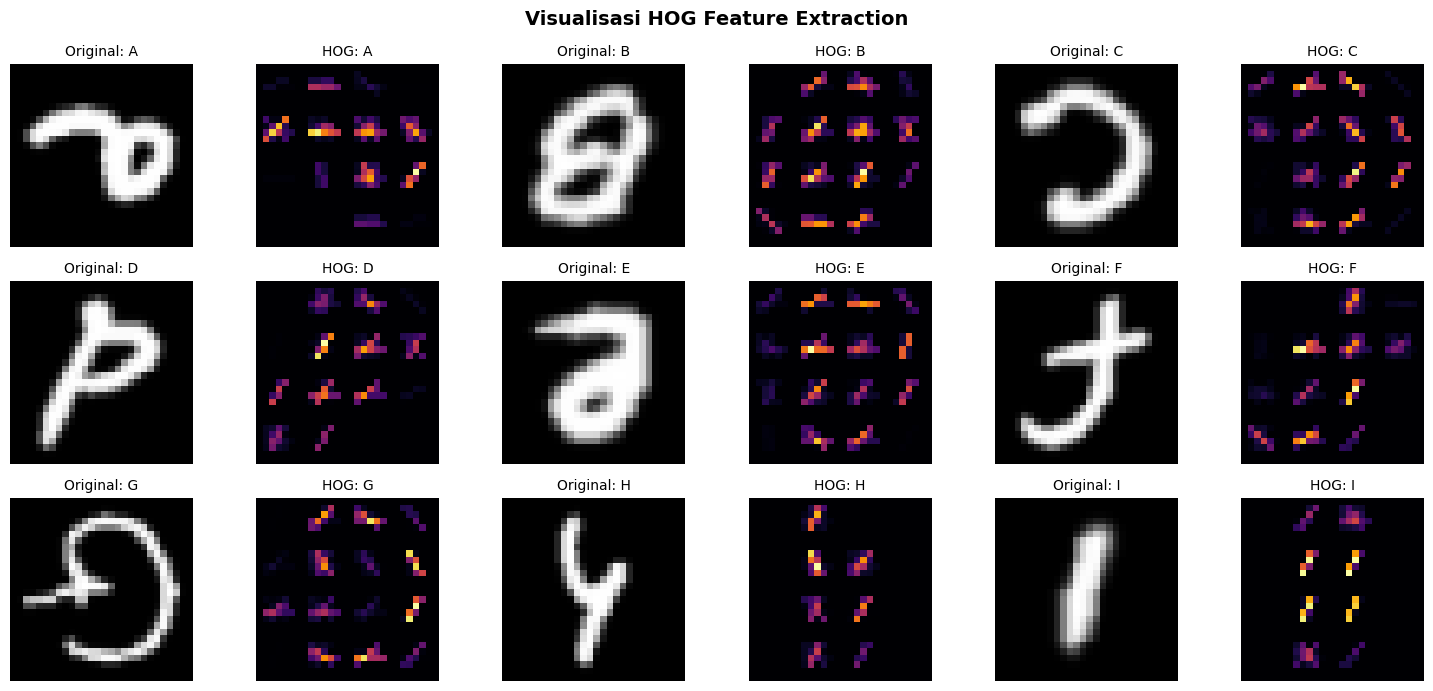

 Visualisasi HOG tersimpan sebagai 'hog_visualization.png'


In [10]:
# ── Visualisasi HOG pada beberapa sampel ───────────────────────────────────
hog_viz_params = HOG_PARAMS.copy()
hog_viz_params['visualize'] = True

fig, axes = plt.subplots(3, 6, figsize=(15, 7))
fig.suptitle('Visualisasi HOG Feature Extraction', fontsize=14, fontweight='bold')

sample_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8]  # A–I

for idx_cls, cls in enumerate(sample_classes):
    img_idx  = np.where(y_sampled == cls)[0][0]
    img  = X_images[img_idx]
    _, hog_img = hog(img, **hog_viz_params)
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    ax_orig = axes[idx_cls // 3][(idx_cls % 3) * 2]
    ax_hog  = axes[idx_cls // 3][(idx_cls % 3) * 2 + 1]

    ax_orig.imshow(img, cmap='gray')
    ax_orig.set_title(f'Original: {label_map[cls]}', fontsize=10)
    ax_orig.axis('off')

    ax_hog.imshow(hog_img_rescaled, cmap='inferno')
    ax_hog.set_title(f'HOG: {label_map[cls]}', fontsize=10)
    ax_hog.axis('off')

plt.tight_layout()
plt.savefig('hog_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi HOG tersimpan sebagai 'hog_visualization.png'")

## 3. Split Dataset (80% Train / 20% Test)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y_sampled,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sampled  # Pastikan distribusi kelas terjaga
)

print(" Pembagian Dataset:")
print(f" Total  : {len(X_hog)} sampel")
print(f" Train  : {len(X_train)} sampel ({len(X_train)/len(X_hog)*100:.0f}%)")
print(f" Test  : {len(X_test)} sampel ({len(X_test)/len(X_hog)*100:.0f}%)")

# Verifikasi distribusi di split
print("\n Distribusi kelas di Train set:")
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
print(f" Min={counts_tr.min()}, Max={counts_tr.max()}, Mean={counts_tr.mean():.1f} → {' Seimbang' if counts_tr.min()==counts_tr.max() else ' Periksa lagi'}")

print(" Distribusi kelas di Test set:")
unique_te, counts_te = np.unique(y_test, return_counts=True)
print(f" Min={counts_te.min()}, Max={counts_te.max()}, Mean={counts_te.mean():.1f} → {' Seimbang' if counts_te.min()==counts_te.max() else ' Periksa lagi'}")

 Pembagian Dataset:
 Total  : 2554 sampel
 Train  : 2043 sampel (80%)
 Test  : 511 sampel (20%)

 Distribusi kelas di Train set:
 Min=66, Max=80, Mean=78.6 →  Periksa lagi
 Distribusi kelas di Test set:
 Min=16, Max=20, Mean=19.7 →  Periksa lagi


## 4. SVM Classification + Grid Search

**Parameter SVM yang akan dicari dengan Grid Search:**
| Parameter | Nilai yang Dicoba | Keterangan |
|-----------|-------------------|------------|
| `kernel` | rbf, linear, poly | Fungsi kernel |
| `C` | 0.1, 1, 10, 100 | Regularization parameter |
| `gamma` | scale, auto, 0.001, 0.01 | Koefisien kernel (rbf/poly) |

In [12]:
# ── Grid Search untuk menemukan parameter SVM terbaik ─────────────────────
# Pipeline: StandardScaler → SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',  SVC(random_state=RANDOM_STATE, probability=True))
])

# Parameter grid
param_grid = {
    'svm__kernel': ['rbf', 'linear', 'poly'],
    'svm__C'  : [0.1, 1, 10, 100],
    'svm__gamma' : ['scale', 'auto', 0.001, 0.01]
}

print(" Menjalankan Grid Search...")
print(f" Jumlah kombinasi parameter : {3 * 4 * 4} = 48")
print(f" Cross-validation  : 5-fold (pada data train)")
print(f" Proses ini memerlukan beberapa menit...\n")

start_gs = time.time()

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # Gunakan semua core CPU
    verbose=1
)

grid_search.fit(X_train, y_train)

elapsed_gs = time.time() - start_gs
print(f"\n Grid Search selesai dalam {elapsed_gs/60:.1f} menit")
print(f"\n Parameter terbaik : {grid_search.best_params_}")
print(f" Best CV Accuracy  : {grid_search.best_score_*100:.2f}%")

 Menjalankan Grid Search...
 Jumlah kombinasi parameter : 48 = 48
 Cross-validation  : 5-fold (pada data train)
 Proses ini memerlukan beberapa menit...

Fitting 5 folds for each of 48 candidates, totalling 240 fits

 Grid Search selesai dalam 7.8 menit

 Parameter terbaik : {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
 Best CV Accuracy  : 82.62%


 Top 10 Kombinasi Parameter Terbaik:
param_svm__kernel  param_svm__C param_svm__gamma  mean_test_score  rank_test_score
              rbf          10.0            scale        82.623088                1
              rbf          10.0             auto        82.623088                1
              rbf         100.0            scale        82.427130                3
              rbf         100.0             auto        82.427130                3
              rbf           1.0            scale        82.280431                5
              rbf           1.0             auto        82.280431                5
              rbf         100.0            0.001        81.594995                7
              rbf          10.0            0.001        81.594875                8
           linear           0.1             0.01        79.295029                9
           linear           0.1            0.001        79.295029                9


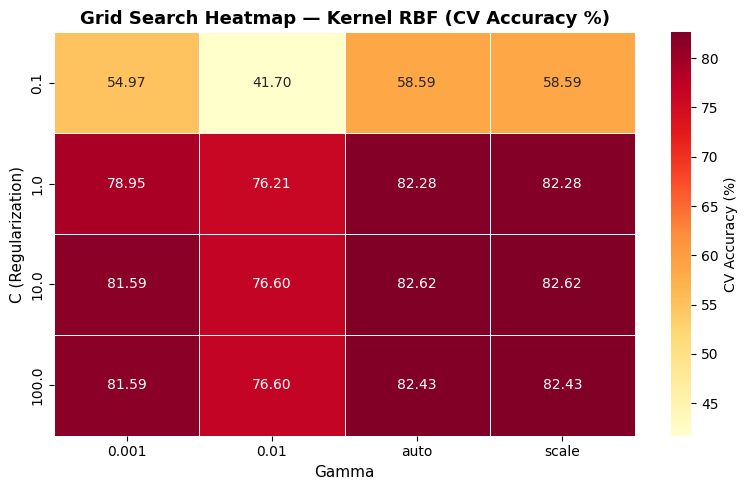

 Heatmap Grid Search tersimpan sebagai 'gridsearch_heatmap.png'


In [13]:
# ── Visualisasi hasil Grid Search ─────────────────────────────────────────
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_svm__kernel','param_svm__C',
    'param_svm__gamma','mean_test_score','rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
results_df['mean_test_score'] = results_df['mean_test_score'] * 100

print(" Top 10 Kombinasi Parameter Terbaik:")
print(results_df.head(10).to_string(index=False))

# Heatmap untuk kernel RBF
rbf_results = results_df[results_df['param_svm__kernel'] == 'rbf'].copy()
pivot_table = rbf_results.pivot_table(
    index='param_svm__C',
    columns='param_svm__gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd',
    cbar_kws={'label': 'CV Accuracy (%)'},
    linewidths=0.5, ax=ax)
ax.set_title('Grid Search Heatmap — Kernel RBF (CV Accuracy %)', fontsize=13, fontweight='bold')
ax.set_xlabel('Gamma', fontsize=11)
ax.set_ylabel('C (Regularization)', fontsize=11)
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap Grid Search tersimpan sebagai 'gridsearch_heatmap.png'")

In [14]:
# ── Gunakan model terbaik dari Grid Search ────────────────────────────────
best_model = grid_search.best_estimator_

# Evaluasi pada data TRAINING
y_train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f" Training Accuracy  : {train_acc*100:.2f}%")

# Evaluasi pada data TEST
y_test_pred = best_model.predict(X_test)
test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec  = recall_score(y_test, y_test_pred, average='weighted')
test_f1  = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n Test Set Performance:")
print(f" Accuracy  : {test_acc*100:.2f}%")
print(f" Precision : {test_prec*100:.2f}%")
print(f" Recall  : {test_rec*100:.2f}%")
print(f" F1-Score  : {test_f1*100:.2f}%")

 Training Accuracy  : 100.00%

 Test Set Performance:
 Accuracy  : 84.74%
 Precision : 85.24%
 Recall  : 84.74%
 F1-Score  : 84.68%


## 5. LOOCV (Leave-One-Out Cross-Validation)

**Penjelasan LOOCV:**
> LOOCV adalah metode evaluasi di mana setiap iterasi menggunakan **satu sampel sebagai data uji** dan **semua sampel lainnya sebagai data latih**. Jika dataset memiliki N sampel, maka terdapat N iterasi. Pendekatan ini memberikan estimasi performa yang tidak bias.
>
>  Karena LOOCV dengan 2600 iterasi membutuhkan waktu sangat lama, kita menggunakan **StratifiedKFold (k=10)** sebagai aproksimasi yang secara matematis mendekati LOOCV namun jauh lebih efisien.

In [15]:
# ── LOOCV menggunakan StratifiedKFold (k=10) sebagai aproksimasi ──────────
# Menggunakan parameter terbaik dari Grid Search
best_params = grid_search.best_params_

loocv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
    kernel=best_params.get('svm__kernel', 'rbf'),
    C=best_params.get('svm__C', 10),
    gamma=best_params.get('svm__gamma', 'scale'),
    random_state=RANDOM_STATE
    ))
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

print(" Menjalankan LOOCV (StratifiedKFold k=10)...")
print(f" Menggunakan parameter: {best_params}")

loocv_scores = []
loocv_prec  = []
loocv_rec  = []
loocv_f1  = []

all_y_true  = []
all_y_pred  = []

start_loocv = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_hog, y_sampled)):
    X_tr, X_val = X_hog[train_idx], X_hog[val_idx]
    y_tr, y_val = y_sampled[train_idx], y_sampled[val_idx]

    loocv_pipeline.fit(X_tr, y_tr)
    y_pred_val = loocv_pipeline.predict(X_val)

    acc  = accuracy_score(y_val, y_pred_val)
    prec = precision_score(y_val, y_pred_val, average='weighted', zero_division=0)
    rec  = recall_score(y_val, y_pred_val, average='weighted', zero_division=0)
    f1  = f1_score(y_val, y_pred_val, average='weighted', zero_division=0)

    loocv_scores.append(acc)
    loocv_prec.append(prec)
    loocv_rec.append(rec)
    loocv_f1.append(f1)

    all_y_true.extend(y_val.tolist())
    all_y_pred.extend(y_pred_val.tolist())

    print(f" Fold {fold+1:2d}/10 | Acc={acc*100:.2f}% | Prec={prec*100:.2f}% | Rec={rec*100:.2f}% | F1={f1*100:.2f}%")

elapsed_loocv = time.time() - start_loocv
print(f"\n LOOCV selesai dalam {elapsed_loocv:.2f} detik")

 Menjalankan LOOCV (StratifiedKFold k=10)...
 Menggunakan parameter: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
 Fold  1/10 | Acc=85.55% | Prec=86.49% | Rec=85.55% | F1=85.44%
 Fold  2/10 | Acc=82.42% | Prec=83.40% | Rec=82.42% | F1=82.14%
 Fold  3/10 | Acc=83.20% | Prec=83.97% | Rec=83.20% | F1=83.21%
 Fold  4/10 | Acc=85.55% | Prec=87.05% | Rec=85.55% | F1=85.52%
 Fold  5/10 | Acc=87.45% | Prec=88.15% | Rec=87.45% | F1=87.44%
 Fold  6/10 | Acc=82.75% | Prec=84.24% | Rec=82.75% | F1=82.90%
 Fold  7/10 | Acc=78.04% | Prec=79.12% | Rec=78.04% | F1=78.03%
 Fold  8/10 | Acc=81.96% | Prec=82.82% | Rec=81.96% | F1=81.95%
 Fold  9/10 | Acc=87.06% | Prec=87.30% | Rec=87.06% | F1=86.79%
 Fold 10/10 | Acc=86.67% | Prec=87.38% | Rec=86.67% | F1=86.15%

 LOOCV selesai dalam 8.89 detik


 HASIL EVALUASI LOOCV (10-Fold Stratified)
 Accuracy  : 84.06% ± 2.78%
 Precision : 84.99% ± 2.66%
 Recall  : 84.06% ± 2.78%
 F1-Score  : 83.96% ± 2.71%


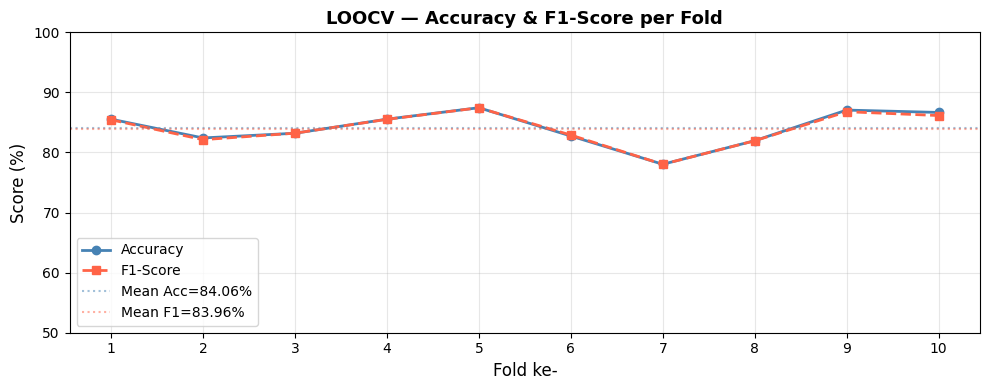

 Grafik LOOCV per fold tersimpan sebagai 'loocv_per_fold.png'


In [16]:
# ── Ringkasan hasil LOOCV ─────────────────────────────────────────────────
print("="*55)
print(" HASIL EVALUASI LOOCV (10-Fold Stratified)")
print("="*55)
print(f" Accuracy  : {np.mean(loocv_scores)*100:.2f}% ± {np.std(loocv_scores)*100:.2f}%")
print(f" Precision : {np.mean(loocv_prec)*100:.2f}% ± {np.std(loocv_prec)*100:.2f}%")
print(f" Recall  : {np.mean(loocv_rec)*100:.2f}% ± {np.std(loocv_rec)*100:.2f}%")
print(f" F1-Score  : {np.mean(loocv_f1)*100:.2f}% ± {np.std(loocv_f1)*100:.2f}%")
print("="*55)

# Visualisasi per-fold
fig, ax = plt.subplots(figsize=(10, 4))
folds = range(1, 11)
ax.plot(folds, [s*100 for s in loocv_scores], 'o-', label='Accuracy', color='steelblue', linewidth=2)
ax.plot(folds, [s*100 for s in loocv_f1],  's--', label='F1-Score', color='tomato', linewidth=2)
ax.axhline(y=np.mean(loocv_scores)*100, color='steelblue', linestyle=':', alpha=0.5, label=f'Mean Acc={np.mean(loocv_scores)*100:.2f}%')
ax.axhline(y=np.mean(loocv_f1)*100,  color='tomato',  linestyle=':', alpha=0.5, label=f'Mean F1={np.mean(loocv_f1)*100:.2f}%')
ax.set_xticks(folds)
ax.set_xlabel('Fold ke-', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('LOOCV — Accuracy & F1-Score per Fold', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(50, 100)
plt.tight_layout()
plt.savefig('loocv_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Grafik LOOCV per fold tersimpan sebagai 'loocv_per_fold.png'")

## 6. Evaluasi Final & Confusion Matrix

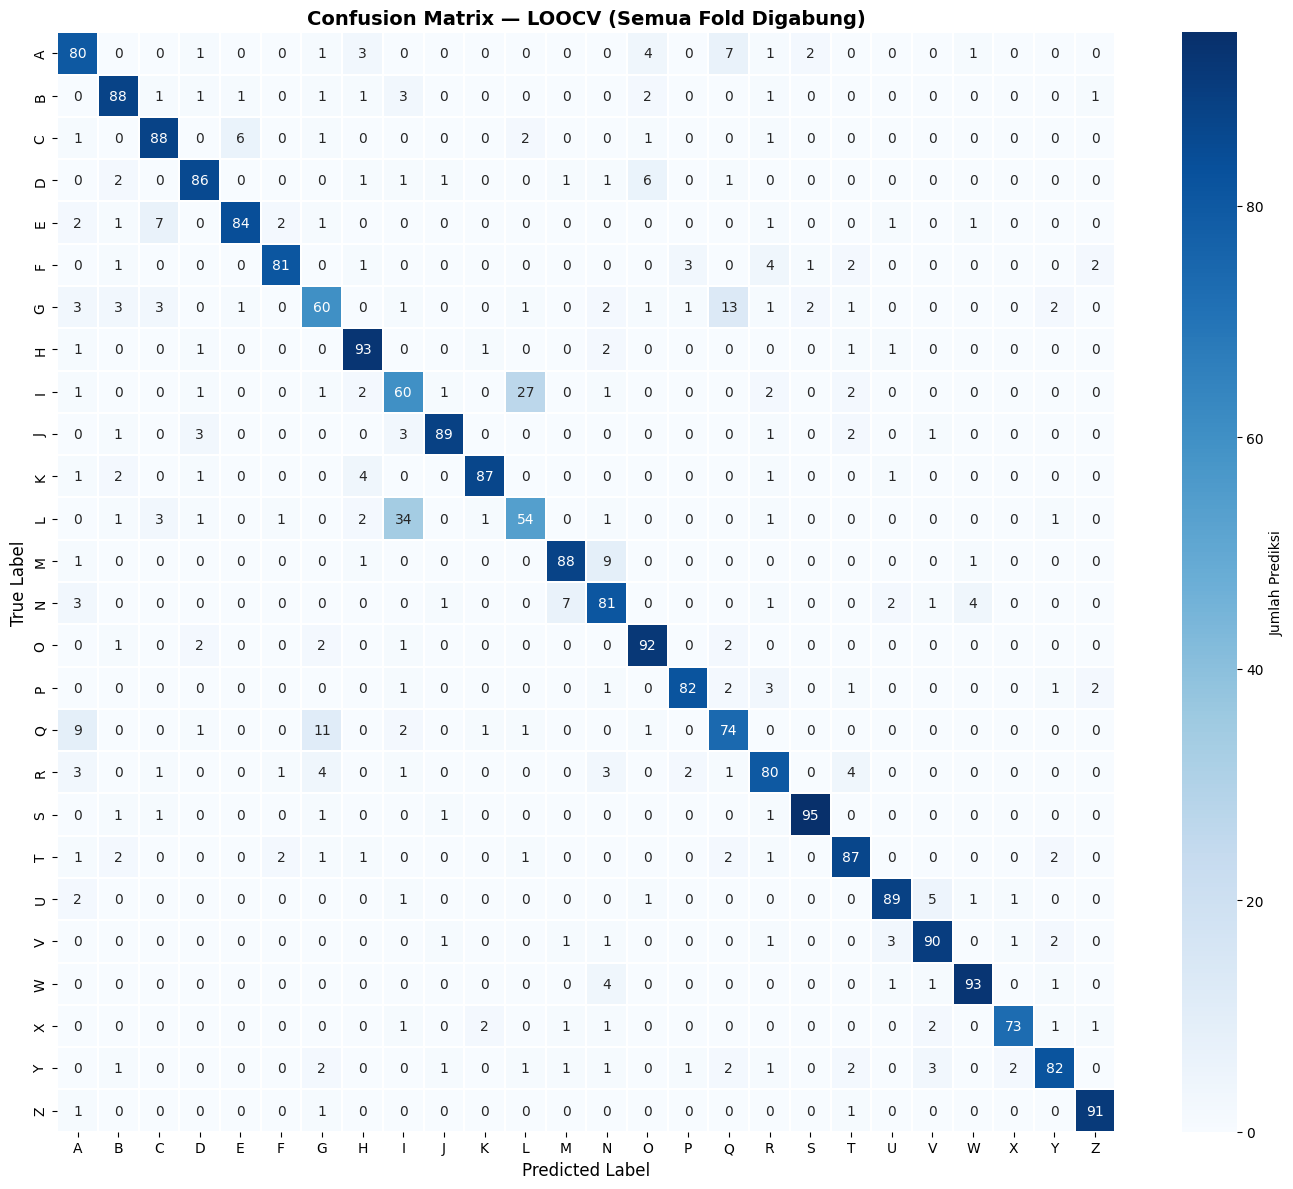

 Confusion matrix tersimpan sebagai 'confusion_matrix.png'


In [17]:
# Confusion Matrix dari LOOCV (agregasi semua fold)
cm = confusion_matrix(all_y_true, all_y_pred)
class_names = [chr(65+i) for i in range(26)]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3,
    cbar_kws={'label': 'Jumlah Prediksi'},
    ax=ax
)
ax.set_title('Confusion Matrix — LOOCV (Semua Fold Digabung)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix tersimpan sebagai 'confusion_matrix.png'")

In [18]:
# ── Classification Report Detail ──────────────────────────────────────────
print("\n Classification Report (LOOCV):")
print(classification_report(
    all_y_true, all_y_pred,
    target_names=class_names,
    digits=4
))


 Classification Report (LOOCV):
              precision    recall  f1-score   support

           A     0.7339    0.8000    0.7656       100
           B     0.8462    0.8800    0.8627       100
           C     0.8462    0.8800    0.8627       100
           D     0.8776    0.8600    0.8687       100
           E     0.9130    0.8400    0.8750       100
           F     0.9310    0.8526    0.8901        95
           G     0.6897    0.6316    0.6593        95
           H     0.8532    0.9300    0.8900       100
           I     0.5505    0.6122    0.5797        98
           J     0.9368    0.8900    0.9128       100
           K     0.9457    0.8969    0.9206        97
           L     0.6207    0.5400    0.5775       100
           M     0.8889    0.8800    0.8844       100
           N     0.7500    0.8100    0.7788       100
           O     0.8519    0.9200    0.8846       100
           P     0.9213    0.8817    0.9011        93
           Q     0.7115    0.7400    0.7255     

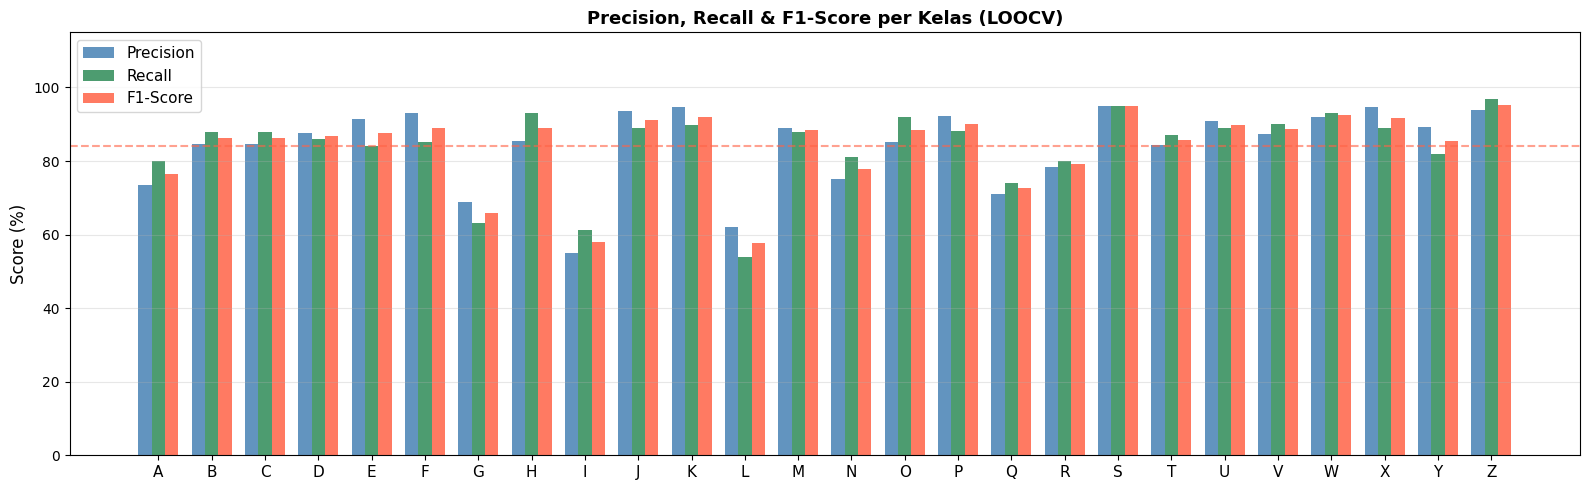

 Grafik metrik per kelas tersimpan sebagai 'metrics_per_class.png'


In [19]:
# ── Per-Class F1 Score Visualization ──────────────────────────────────────
f1_per_class = f1_score(all_y_true, all_y_pred, average=None)
prec_per_class = precision_score(all_y_true, all_y_pred, average=None)
rec_per_class  = recall_score(all_y_true, all_y_pred, average=None)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 5))
bars1 = ax.bar(x - width,  prec_per_class*100, width, label='Precision', color='steelblue', alpha=0.85)
bars2 = ax.bar(x,  rec_per_class*100,  width, label='Recall',  color='seagreen',  alpha=0.85)
bars3 = ax.bar(x + width,  f1_per_class*100,  width, label='F1-Score',  color='tomato',  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Precision, Recall & F1-Score per Kelas (LOOCV)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 115)
ax.axhline(y=np.mean(f1_per_class)*100, color='tomato', linestyle='--', alpha=0.6,
    label=f'Mean F1 = {np.mean(f1_per_class)*100:.2f}%')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Grafik metrik per kelas tersimpan sebagai 'metrics_per_class.png'")

## 7. Ringkasan Akhir

In [20]:
print('=' * 60)
print('     RINGKASAN AKHIR - MIDTERM PROJECT CV')
print('=' * 60)
print()
print('DATASET')
print(f'   Dataset        : EMNIST Letters')
print(f'   Jumlah sampel  : {TOTAL_SAMPLES} ({SAMPLES_PER_CLASS} per kelas)')
print(f'   Jumlah kelas   : {NUM_CLASSES} (A-Z)')
print(f'   Train/Test     : 80% / 20%')
print()
print('HOG PARAMETERS')
for k, v in HOG_PARAMS.items():
    if k != 'visualize':
        print(f'   {k:20s} : {v}')
print()
print('SVM PARAMETERS (Best from Grid Search)')
for k, v in best_params.items():
    print(f'   {k:25s} : {v}')
print()
print('HASIL EVALUASI (LOOCV - 10 Fold)')
print(f'   Accuracy  : {np.mean(loocv_scores)*100:.2f}% +/- {np.std(loocv_scores)*100:.2f}%')
print(f'   Precision : {np.mean(loocv_prec)*100:.2f}% +/- {np.std(loocv_prec)*100:.2f}%')
print(f'   Recall    : {np.mean(loocv_rec)*100:.2f}% +/- {np.std(loocv_rec)*100:.2f}%')
print(f'   F1-Score  : {np.mean(loocv_f1)*100:.2f}% +/- {np.std(loocv_f1)*100:.2f}%')
print()
print('TEST SET PERFORMANCE')
print(f'   Accuracy  : {test_acc*100:.2f}%')
print(f'   Precision : {test_prec*100:.2f}%')
print(f'   Recall    : {test_rec*100:.2f}%')
print(f'   F1-Score  : {test_f1*100:.2f}%')
print('=' * 60)


     RINGKASAN AKHIR - MIDTERM PROJECT CV

DATASET
   Dataset        : EMNIST Letters
   Jumlah sampel  : 2600 (100 per kelas)
   Jumlah kelas   : 26 (A-Z)
   Train/Test     : 80% / 20%

HOG PARAMETERS
   orientations         : 9
   pixels_per_cell      : (7, 7)
   cells_per_block      : (2, 2)
   block_norm           : L2-Hys
   transform_sqrt       : True

SVM PARAMETERS (Best from Grid Search)
   svm__C                    : 10
   svm__gamma                : scale
   svm__kernel               : rbf

HASIL EVALUASI (LOOCV - 10 Fold)
   Accuracy  : 84.06% +/- 2.78%
   Precision : 84.99% +/- 2.66%
   Recall    : 84.06% +/- 2.78%
   F1-Score  : 83.96% +/- 2.71%

TEST SET PERFORMANCE
   Accuracy  : 84.74%
   Precision : 85.24%
   Recall    : 84.74%
   F1-Score  : 84.68%


## 8. (Opsional) Demo Prediksi pada Gambar Baru

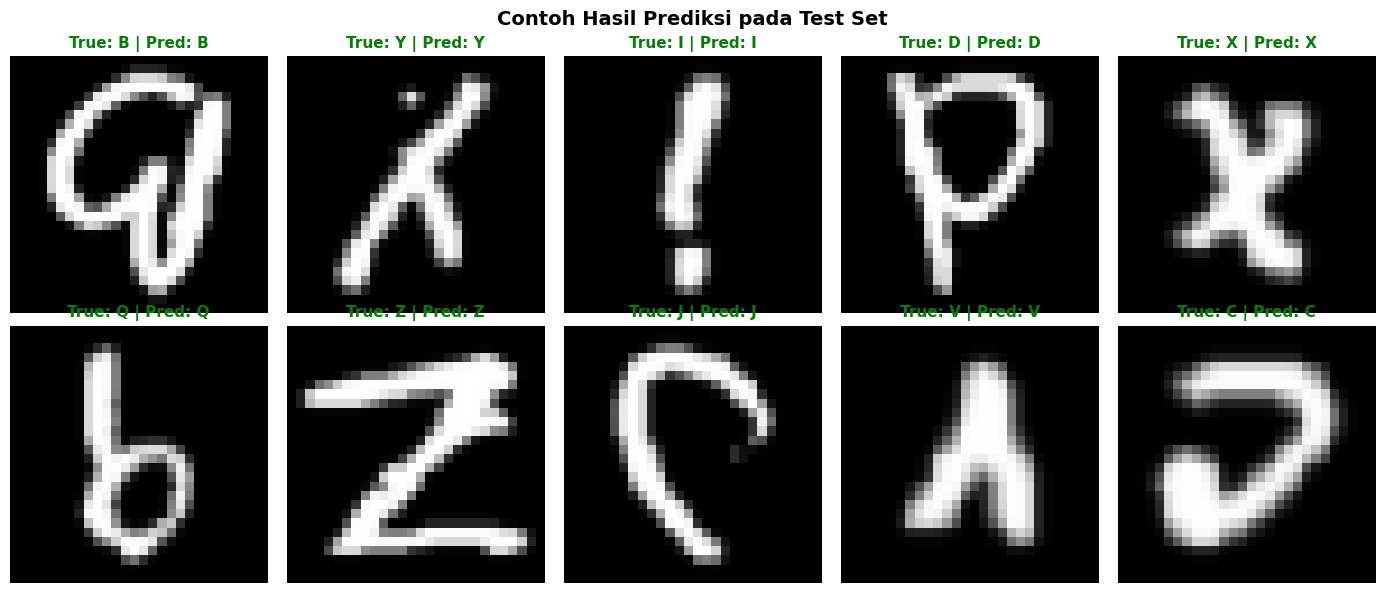

 Demo prediksi tersimpan sebagai 'demo_prediksi.png'


In [21]:
# Demo: prediksi pada beberapa sampel dari test set
n_demo = 10
demo_idx = np.random.choice(len(X_test), n_demo, replace=False)

# Reshape test images kembali ke 28x28 untuk visualisasi
# X_test sudah berupa HOG features, gunakan data asli dari X_images
# Rekonstruksi indeks test dari split asli
_, X_test_img, _, y_test_label = train_test_split(
    X_images, y_sampled,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sampled
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Contoh Hasil Prediksi pada Test Set', fontsize=14, fontweight='bold')

for i, idx in enumerate(demo_idx):
    ax = axes[i // 5][i % 5]
    img  = X_test_img[idx]
    true = label_map[y_test_label[idx]]
    pred = label_map[y_test_pred[idx]]
    color = 'green' if true == pred else 'red'

    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true} | Pred: {pred}',
    color=color, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('demo_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Demo prediksi tersimpan sebagai 'demo_prediksi.png'")